In [8]:
import numpy as np
import simpful
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go

In [9]:
FS = simpful.FuzzySystem(show_banner=False)

## Entry variables

### Minimum distance to promotion

In [10]:
small = simpful.FuzzySet(points=[[0, 1.0], [4, 0.0]], term="small")
medium = simpful.TriangleFuzzySet(1, 4, 6, term="medium")
large = simpful.FuzzySet(points=[[4, 0.0], [6, 1.0]], term="large")


FS.add_linguistic_variable(
    "Min_Distance_To_Promotion",
    simpful.LinguisticVariable(
        [small, medium, large],
        universe_of_discourse=[0, 6]
    )
)

### Passed pawn count

Actually, pawns on the same file only count as one.

In [11]:
few = simpful.FuzzySet(points=[[0, 1.0], [3, 0.0]], term="few")
many = simpful.FuzzySet(points=[[0, 0.0], [3, 1.0]], term="many")

FS.add_linguistic_variable(
    "Passed_Pawns",
    simpful.LinguisticVariable(
        [few, many],
        universe_of_discourse=[0, 8]
    )
)

## Output variable: Promotion Chances

In [12]:
desired_universe = [-10, 10]
terms = ["very_bad", "bad", "neutral", "good", "very_good"]
n_terms = len(terms)
centers = np.linspace(desired_universe[0], desired_universe[1], n_terms)
width = centers[1] - centers[0]
universe = [desired_universe[0] - width, desired_universe[1] + width]

fuzzy_sets = []

for i in range(n_terms):
    a = centers[i] - width
    b = centers[i]
    c = centers[i] + width

    fuzzy_sets.append(simpful.TriangleFuzzySet(a, b, c, term=terms[i]))

FS.add_linguistic_variable(
    "Promotion_Chances",
    simpful.LinguisticVariable(
        fuzzy_sets,
        universe_of_discourse=universe
    )
)

## Rule system

In [13]:
rules = [
    # Low forward presence
    "IF (Min_Distance_To_Promotion IS small) AND (Passed_Pawns IS few) THEN (Promotion_Chances IS neutral)",
    "IF (Min_Distance_To_Promotion IS medium) AND (Passed_Pawns IS few) THEN (Promotion_Chances IS bad)",
    "IF (Min_Distance_To_Promotion IS large) AND (Passed_Pawns IS few) THEN (Promotion_Chances IS very_bad)",

    # High forward presence
    "IF (Min_Distance_To_Promotion IS small) AND (Passed_Pawns IS many) THEN (Promotion_Chances IS very_good)",
    "IF (Min_Distance_To_Promotion IS medium) AND (Passed_Pawns IS many) THEN (Promotion_Chances IS good)",
    "IF (Min_Distance_To_Promotion IS large) AND (Passed_Pawns IS many) THEN (Promotion_Chances IS good)",
]

FS._rules = []
FS.add_rules(rules)

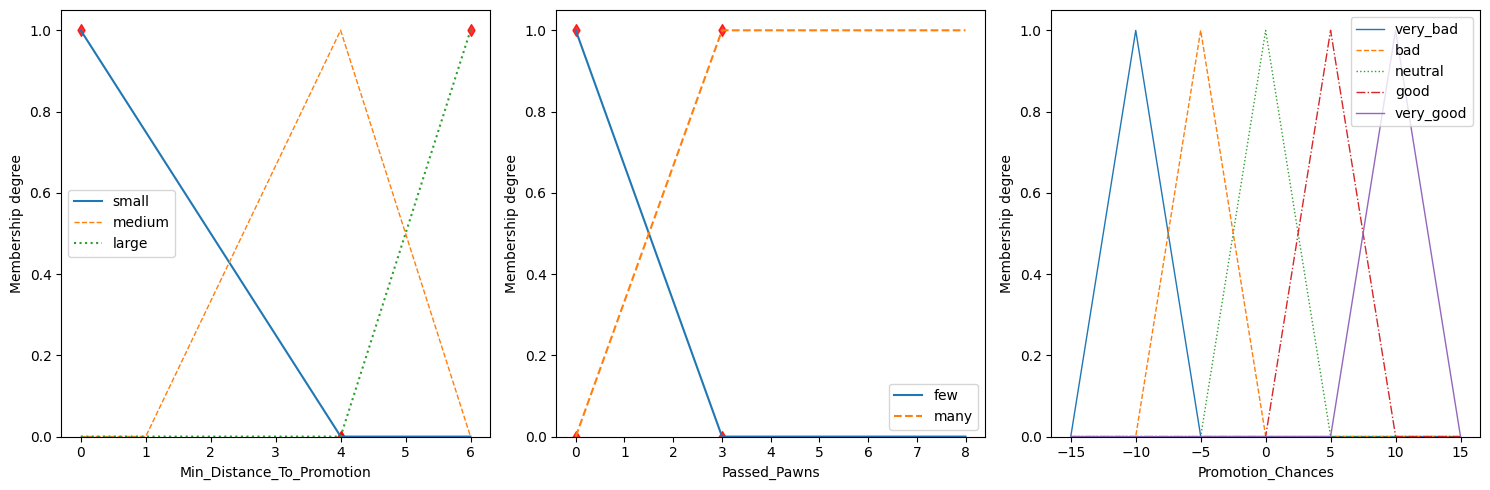

In [14]:
FS.produce_figure()

## Response surface

### Calculations

In [15]:
# Define grid resolution (higher = smoother surface, but slower to compute)
resolution = 25

# Evaluate fuzzy system on a 2D mesh
# Create the 2D meshgrid
x_min_distance = np.linspace(1, 6, resolution)
y_passed_pawns = np.linspace(0, 4, resolution)
X, Y = np.meshgrid(x_min_distance, y_passed_pawns)
Z = np.zeros_like(X)

# Evaluate the fuzzy system at each point on the mesh
for i in range(X.shape[0]):
    for j in range(X.shape[1]):
        FS.set_variable("Min_Distance_To_Promotion", float(X[i, j]))
        FS.set_variable("Passed_Pawns", float(Y[i, j]))
        
        # Run inference
        result = FS.inference()
        Z[i, j] = result["Promotion_Chances"]

### Configure and show plot

In [16]:
# Create the interactive 3D plot with Plotly
fig = go.Figure(data=[go.Surface(
    z=Z, 
    x=X, 
    y=Y, 
    colorscale='Viridis',
    showscale=False, # Removes the colorbar on the side
    hovertemplate='Min. Distance (X): %{x:.2f}<br>Passed Pawns (Y): %{y:.2f}<br>Promotion Chances (Z): %{z:.2f}<extra></extra>'
)])

# Configure layout, titles, camera, and proportions
fig.update_layout(
    title='Promotion Chances Response Surface',
    scene=dict(
        xaxis_title='Min. Distance',
        yaxis_title='Passed Pawns',
        zaxis_title='Promotion Chances',
        aspectmode='cube', # Forces the visual base of the plot to be square
        camera=dict(
            eye=dict(x=1.5, y=-1.5, z=1.2)
        )
    ),
    width=600, 
    height=500,
    margin=dict(l=10, r=0, b=30, t=40) 
)

fig.show()

## Export FIS to lookup table

### Calculate table

In [17]:
# Generate grid
min_distances = np.arange(0, 9)
passed_pawn_counts = np.arange(0, 9)

promotion_chances_lut = np.zeros((len(min_distances), len(passed_pawn_counts)))

# Fill table by calculating output for every possible combination
print("Calculating lookup table...")
for i, min_distance in enumerate(min_distances):
    for j, passed_pawns in enumerate(passed_pawn_counts):
        FS.set_variable("Min_Distance_To_Promotion", min_distance)
        FS.set_variable("Passed_Pawns", passed_pawns)

        result = FS.inference()["Promotion_Chances"]
        promotion_chances_lut[i, j] = result

print(f"Lookup table calculated. Shape: {promotion_chances_lut.shape}.")

Calculating lookup table...
Lookup table calculated. Shape: (9, 9).


### Save in file

In [18]:
import os

# Make sure the directory exists
os.makedirs("../data/luts", exist_ok=True)

file_path = "../data/luts/promotion_chances_lut.npy"
np.save(file_path, promotion_chances_lut)

print(f"Successfully saved lookup table as {file_path}.")

Successfully saved lookup table as ../data/luts/promotion_chances_lut.npy.
